Optimal Alpha (Hyperparameter) found: 100.00000
Ridge RMSE: 20.32 minutes
Ridge R² Score: 0.44


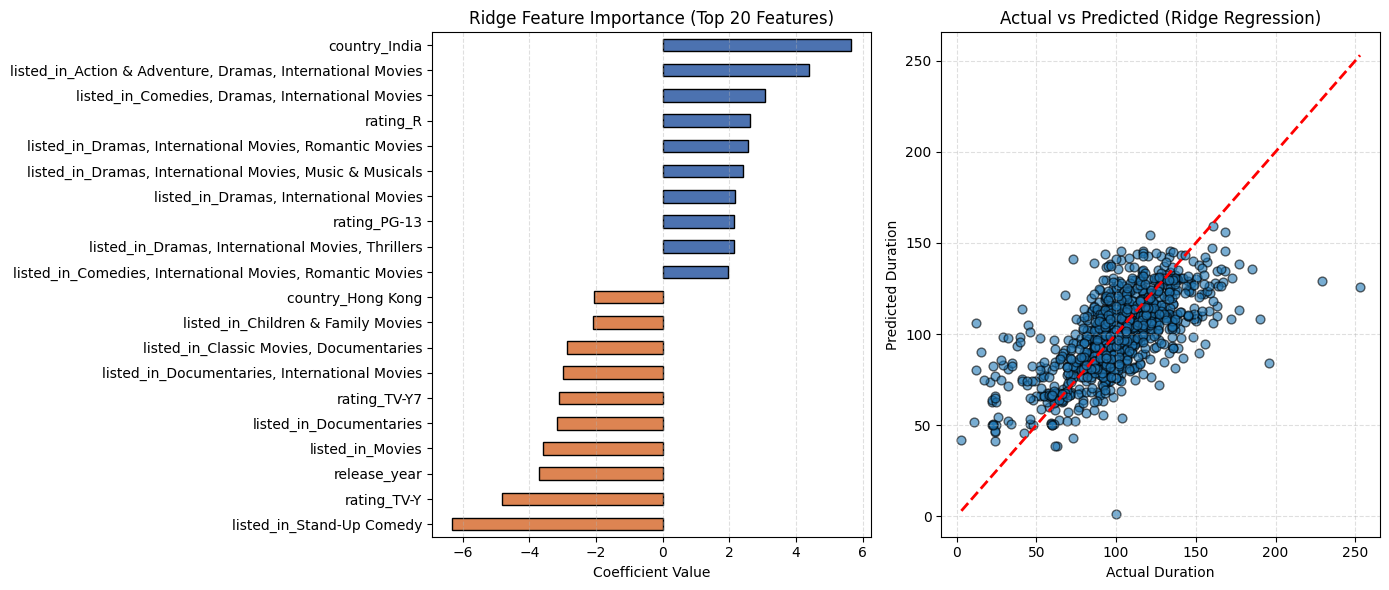


Top 5 Most Important Features (Ridge):
listed_in_Stand-Up Comedy                                     6.315431
country_India                                                 5.644356
rating_TV-Y                                                   4.811566
listed_in_Action & Adventure, Dramas, International Movies    4.383315
release_year                                                  3.708090
dtype: float64


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# =============================
# LOAD NETFLIX DATASET
# =============================
df = pd.read_csv("netflix_titles.csv")

df.columns = df.columns.str.strip()

# =============================
# DATA CLEANING (Netflix Version)
# =============================

# Keep only Movies for regression
df = df[df['type'] == 'Movie'].copy()

# Convert duration text → numeric
df['duration_minutes'] = df['duration'].str.extract(r'(\d+)').astype(float)

# Drop identifier-like columns (same idea as Country/Year)
df = df.drop(['show_id','title','director','cast','date_added','description','duration'], axis=1)

# Handle Missing Values (same style)
df.fillna(df.mode().iloc[0], inplace=True)

# One-Hot Encoding (similar to Status encoding)
df = pd.get_dummies(df, columns=['type','rating','country','listed_in'], drop_first=True)

# =============================
# DEFINE FEATURES + TARGET
# =============================
X = df.drop('duration_minutes', axis=1)
y = df['duration_minutes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =============================
# STANDARDIZATION
# =============================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =============================
# RIDGE REGRESSION
# =============================
alphas_to_test = np.logspace(-2, 2, 50)

ridge_cv = RidgeCV(alphas=alphas_to_test, cv=5)
ridge_cv.fit(X_train_scaled, y_train)

print(f"Optimal Alpha (Hyperparameter) found: {ridge_cv.alpha_:.5f}")

y_pred = ridge_cv.predict(X_test_scaled)

# =============================
# MODEL EVALUATION
# =============================
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Ridge RMSE: {rmse:.2f} minutes")
print(f"Ridge R² Score: {r2:.2f}")
# =============================
# CLEAN VISUALIZATION (UPDATED)
# =============================
plt.figure(figsize=(14,6))

coefs = pd.Series(ridge_cv.coef_, index=X.columns)

# 🔥 Show ONLY top 20 important features (cleaner graph)
top_features = coefs.abs().sort_values(ascending=False).head(20).index
coefs_sorted = coefs.loc[top_features].sort_values()

# ---------- Plot 1: Feature Importance ----------
plt.subplot(1,2,1)

coefs_sorted.plot(
    kind='barh',
    color=(coefs_sorted > 0).map({True:'#4C72B0', False:'#DD8452'}),
    edgecolor='black'
)

plt.title("Ridge Feature Importance (Top 20 Features)", fontsize=12)
plt.xlabel("Coefficient Value")
plt.ylabel("")
plt.grid(True, axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()

# ---------- Plot 2: Actual vs Predicted ----------
plt.subplot(1,2,2)

plt.scatter(
    y_test, y_pred,
    alpha=0.6,
    s=40,
    edgecolors='black'
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--', lw=2
)

plt.xlabel("Actual Duration")
plt.ylabel("Predicted Duration")
plt.title("Actual vs Predicted (Ridge Regression)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('ridge_results_clean.png', dpi=300)
plt.show()
# =============================
# PRINT TOP FEATURES (LIKE ORIGINAL NOTEBOOK)
# =============================
coefs = pd.Series(ridge_cv.coef_, index=X.columns)

print("\nTop 5 Most Important Features (Ridge):")
print(coefs.abs().sort_values(ascending=False).head(5))

